<a href="https://colab.research.google.com/github/drfperez/exoplanets/blob/main/Trappist1b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

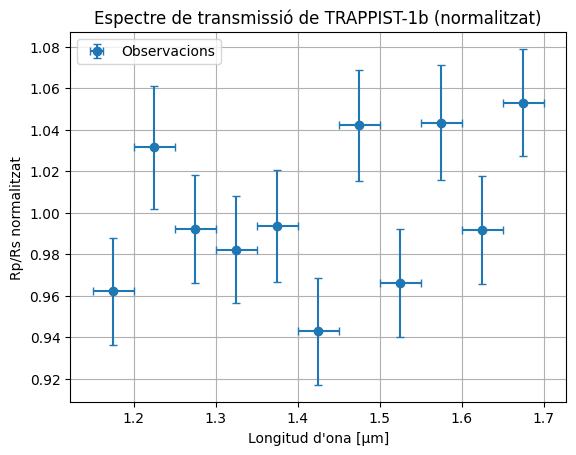

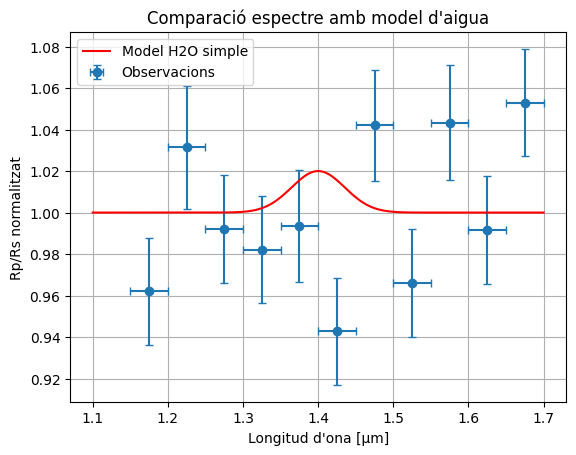

In [ ]:

# -----------------------------------------------
# 1. Importar llibreries
# -----------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------
# 2. Dades de TRAPPIST-1b (WFC3 G141)
# -----------------------------------------------
data = np.array([
    [1.175, 0.05, 0.0077973252, 0.0002082651],
    [1.225, 0.05, 0.0083601016, 0.0002400672],
    [1.275, 0.05, 0.0080395881, 0.0002102117],
    [1.325, 0.05, 0.0079605045, 0.0002097295],
    [1.375, 0.05, 0.0080515811, 0.0002183603],
    [1.425, 0.05, 0.0076416553, 0.0002097285],
    [1.475, 0.05, 0.0084450288, 0.0002175522],
    [1.525, 0.05, 0.0078302323, 0.0002093257],
    [1.575, 0.05, 0.0084564130, 0.0002252069],
    [1.625, 0.05, 0.0080377671, 0.0002119293],
    [1.675, 0.05, 0.0085347202, 0.0002093527]
])

wavelength = data[:,0]       # microns
delta_w = data[:,1]
Rp_Rs_sq = data[:,2]         # (Rp/Rs)^2
err = data[:,3]               # uncertainties

# -----------------------------------------------
# 3. Normalitzar l'espectre (opcional però útil)
# -----------------------------------------------
Rp_Rs_sq_norm = Rp_Rs_sq / np.mean(Rp_Rs_sq)
err_norm = err / np.mean(Rp_Rs_sq)

# -----------------------------------------------
# 4. Dibuixar l'espectre normalitzat
# -----------------------------------------------
plt.errorbar(wavelength, Rp_Rs_sq_norm, yerr=err_norm, xerr=delta_w/2, fmt='o', capsize=3, label="Observacions")
plt.xlabel("Longitud d'ona [μm]")
plt.ylabel("Rp/Rs normalitzat")
plt.title("Espectre de transmissió de TRAPPIST-1b (normalitzat)")
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------------------------
# 5. Comparar amb un model simple d'aigua
# -----------------------------------------------
# Exemple: absorció H2O simulada (picos aproximats)
# Aquesta és només una corba de demostració
w_model = np.linspace(1.1, 1.7, 500)
H2O_model = 1 + 0.02*np.exp(-((w_model-1.4)/0.05)**2)  # pic simulat a 1.4 μm

plt.errorbar(wavelength, Rp_Rs_sq_norm, yerr=err_norm, xerr=delta_w/2, fmt='o', capsize=3, label="Observacions")
plt.plot(w_model, H2O_model, 'r-', label="Model H2O simple")
plt.xlabel("Longitud d'ona [μm]")
plt.ylabel("Rp/Rs normalitzat")
plt.title("Comparació espectre amb model d'aigua")
plt.grid(True)
plt.legend()
plt.show()

Ajust H2O: baseline=1.0055, amp=-0.2310, center=1.405 μm, sigma=0.012 μm
Errors en els paràmetres: [9.36841369e-03 2.85955245e+04 3.22364393e+02 3.95759402e+02]


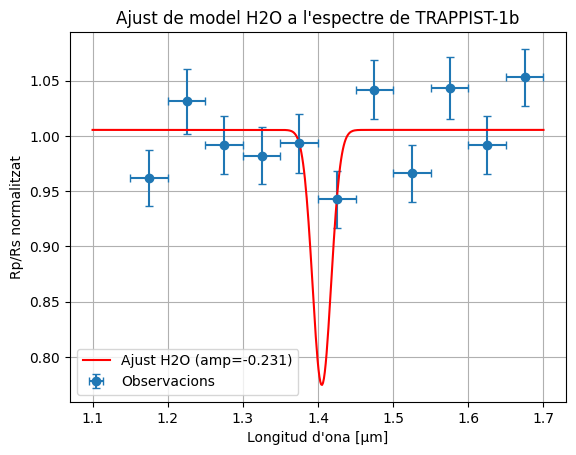

In [ ]:

# -----------------------------------------------
# 1. Importar llibreries addicionals
# -----------------------------------------------
from scipy.optimize import curve_fit

# -----------------------------------------------
# 2. Definir model H2O simple
# -----------------------------------------------
# Model: baseline + pic gaussià d'aigua
def H2O_gaussian(w, baseline, amp, center, sigma):
    return baseline + amp * np.exp(-0.5*((w - center)/sigma)**2)

# -----------------------------------------------
# 3. Parametres inicials del model
# baseline ~ 1, amp ~ 0.02, center ~ 1.4, sigma ~ 0.05
p0 = [1.0, 0.02, 1.4, 0.05]

# -----------------------------------------------
# 4. Ajustar el model a les dades normalitzades
popt, pcov = curve_fit(H2O_gaussian, wavelength, Rp_Rs_sq_norm, sigma=err_norm, absolute_sigma=True, p0=p0)

# Paràmetres ajustats
baseline_fit, amp_fit, center_fit, sigma_fit = popt
print(f"Ajust H2O: baseline={baseline_fit:.4f}, amp={amp_fit:.4f}, center={center_fit:.3f} μm, sigma={sigma_fit:.3f} μm")

# Error en cada paràmetre
perr = np.sqrt(np.diag(pcov))
print("Errors en els paràmetres:", perr)

# -----------------------------------------------
# 5. Dibuixar l'ajust
# -----------------------------------------------
w_model = np.linspace(1.1, 1.7, 500)
plt.errorbar(wavelength, Rp_Rs_sq_norm, yerr=err_norm, xerr=delta_w/2, fmt='o', capsize=3, label="Observacions")
plt.plot(w_model, H2O_gaussian(w_model, *popt), 'r-', label=f"Ajust H2O (amp={amp_fit:.3f})")
plt.xlabel("Longitud d'ona [μm]")
plt.ylabel("Rp/Rs normalitzat")
plt.title("Ajust de model H2O a l'espectre de TRAPPIST-1b")
plt.legend()
plt.grid(True)
plt.show()

Ajust inicial:
 baseline=1.0055, amp=-0.2310
 center=1.405, sigma=0.012

Millor ajust trobat per: baseline=0.9994, amp=-0.0200
Chi² mínim = 18.826


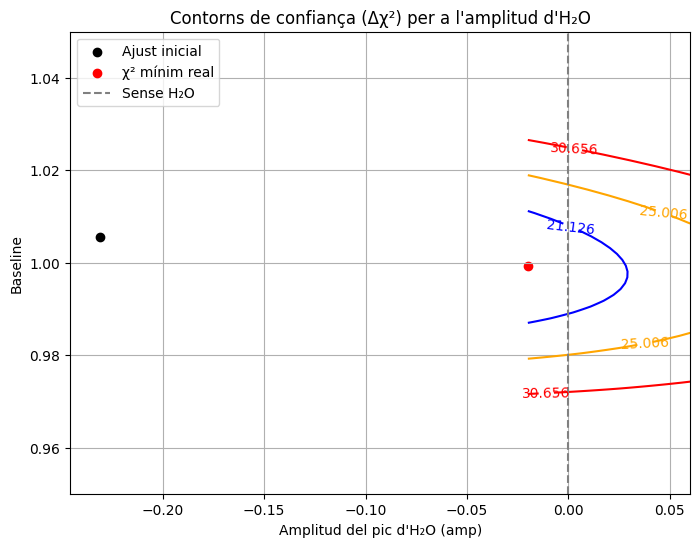

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -----------------------------------------------------------
# 1. Model d'H2O
# -----------------------------------------------------------
def H2O_gaussian(w, baseline, amp, center, sigma):
    return baseline + amp * np.exp(-0.5*((w - center)/sigma)**2)

# -----------------------------------------------------------
# 2. Dades normalitzades (reutilitza les variables si ja les tens carregades)
# -----------------------------------------------------------

# Dades
data = np.array([
    [1.175, 0.05, 0.0077973252, 0.0002082651],
    [1.225, 0.05, 0.0083601016, 0.0002400672],
    [1.275, 0.05, 0.0080395881, 0.0002102117],
    [1.325, 0.05, 0.0079605045, 0.0002097295],
    [1.375, 0.05, 0.0080515811, 0.0002183603],
    [1.425, 0.05, 0.0076416553, 0.0002097285],
    [1.475, 0.05, 0.0084450288, 0.0002175522],
    [1.525, 0.05, 0.0078302323, 0.0002093257],
    [1.575, 0.05, 0.0084564130, 0.0002252069],
    [1.625, 0.05, 0.0080377671, 0.0002119293],
    [1.675, 0.05, 0.0085347202, 0.0002093527]
])

wavelength = data[:,0]
Rp_Rs_sq = data[:,2]
err = data[:,3]

# Normalització
Rp_Rs_sq_norm = Rp_Rs_sq / np.mean(Rp_Rs_sq)
err_norm = err / np.mean(Rp_Rs_sq)

# -----------------------------------------------------------
# 3. Ajust previ per fixar center i sigma
# -----------------------------------------------------------
p0 = [1.0, 0.02, 1.4, 0.05]
popt, pcov = curve_fit(H2O_gaussian, wavelength, Rp_Rs_sq_norm,
                       sigma=err_norm, absolute_sigma=True, p0=p0)
baseline_fit, amp_fit, center_fit, sigma_fit = popt

print("Ajust inicial:")
print(f" baseline={baseline_fit:.4f}, amp={amp_fit:.4f}")
print(f" center={center_fit:.3f}, sigma={sigma_fit:.3f}")

# -----------------------------------------------------------
# 4. Graella de χ² en (baseline, amp)
# -----------------------------------------------------------
baseline_vals = np.linspace(0.95, 1.05, 80)
amp_vals = np.linspace(-0.02, 0.06, 80)

chi2_grid = np.zeros((len(baseline_vals), len(amp_vals)))

for i, b in enumerate(baseline_vals):
    for j, a in enumerate(amp_vals):
        model = H2O_gaussian(wavelength, b, a, center_fit, sigma_fit)
        chi2 = np.sum(((Rp_Rs_sq_norm - model)/err_norm)**2)
        chi2_grid[i, j] = chi2

# -----------------------------------------------------------
# 5. Localitzar mínim χ²
# -----------------------------------------------------------
chi2_min = np.min(chi2_grid)
best_pos = np.unravel_index(np.argmin(chi2_grid), chi2_grid.shape)
b_best = baseline_vals[best_pos[0]]
a_best = amp_vals[best_pos[1]]

print(f"\nMillor ajust trobat per: baseline={b_best:.4f}, amp={a_best:.4f}")
print(f"Chi² mínim = {chi2_min:.3f}")

# -----------------------------------------------------------
# 6. Contorns de confiança
# -----------------------------------------------------------
# Nivells de Δχ² per 2 paràmetres (Press et al. Numerical Recipes)
chi2_levels = chi2_min + np.array([2.30, 6.18, 11.83])  # 1σ, 2σ, 3σ

plt.figure(figsize=(8,6))
CS = plt.contour(amp_vals, baseline_vals, chi2_grid, levels=chi2_levels, colors=['blue','orange','red'])
plt.clabel(CS, inline=True, fontsize=10)

plt.scatter([amp_fit], [baseline_fit], color='black', label="Ajust inicial")
plt.scatter([a_best], [b_best], color='red', label="χ² mínim real")

plt.axvline(0, color='gray', linestyle='--', label="Sense H₂O")

plt.xlabel("Amplitud del pic d'H₂O (amp)")
plt.ylabel("Baseline")
plt.title("Contorns de confiança (Δχ²) per a l'amplitud d'H₂O")
plt.legend()
plt.grid(True)
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.6 MB/s eta 0:00:00
Ajust inicial (least-sq):
 baseline, amp, center, sigma =  [ 1.00553  -0.231012  1.405027  0.012367]
Errors aprox (sqrt diag cov): [9.36800000e-03 2.85955245e+04 3.22364393e+02 3.95759402e+02]
Running MCMC... (pot trigar uns minuts segons nsteps)


100%|██████████| 5000/5000 [00:13<00:00, 361.93it/s]


MCMC finalitzat en 13.8 s
Samples shape (flat): (28000, 4)

Resum posterior (mediana + 1σ interval):
 baseline = 0.997054  (+0.010823/-0.010947)
      amp = 0.020615  (+0.046073/-0.050393)
   center = 1.482315  (+0.189279/-0.259884)
 log_sigma = -3.6572  => sigma = 0.0258 (+0.0811/-0.0173)


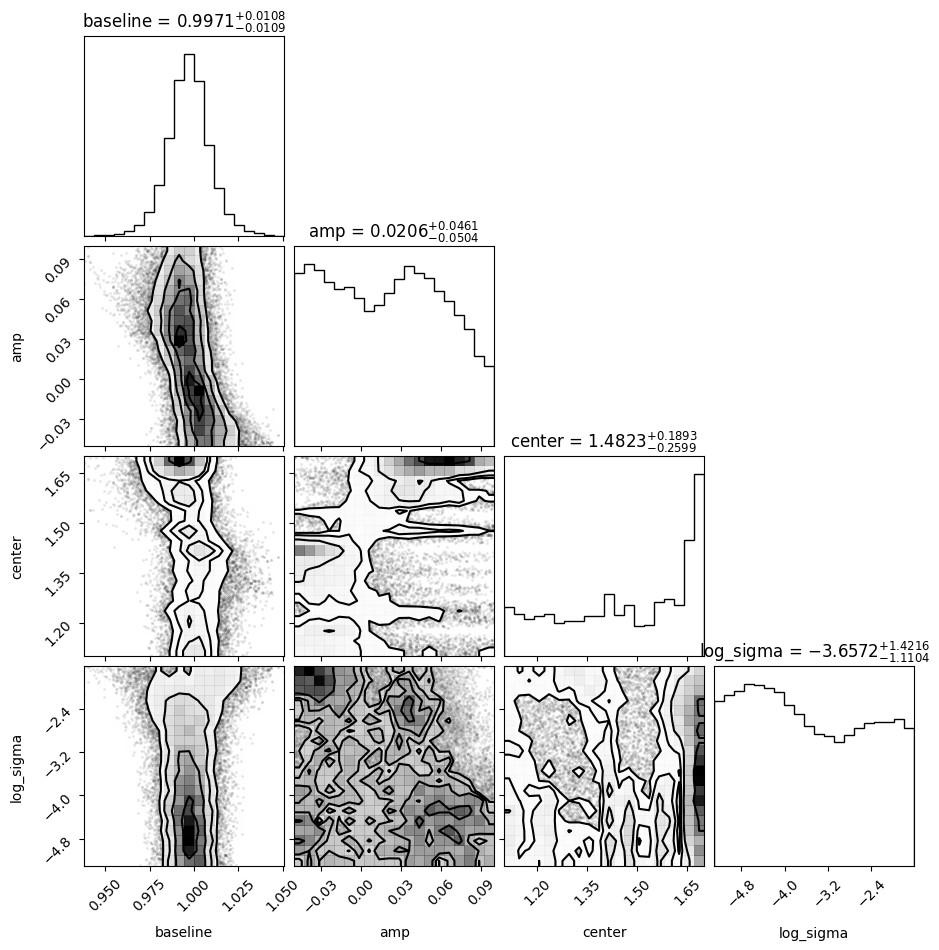

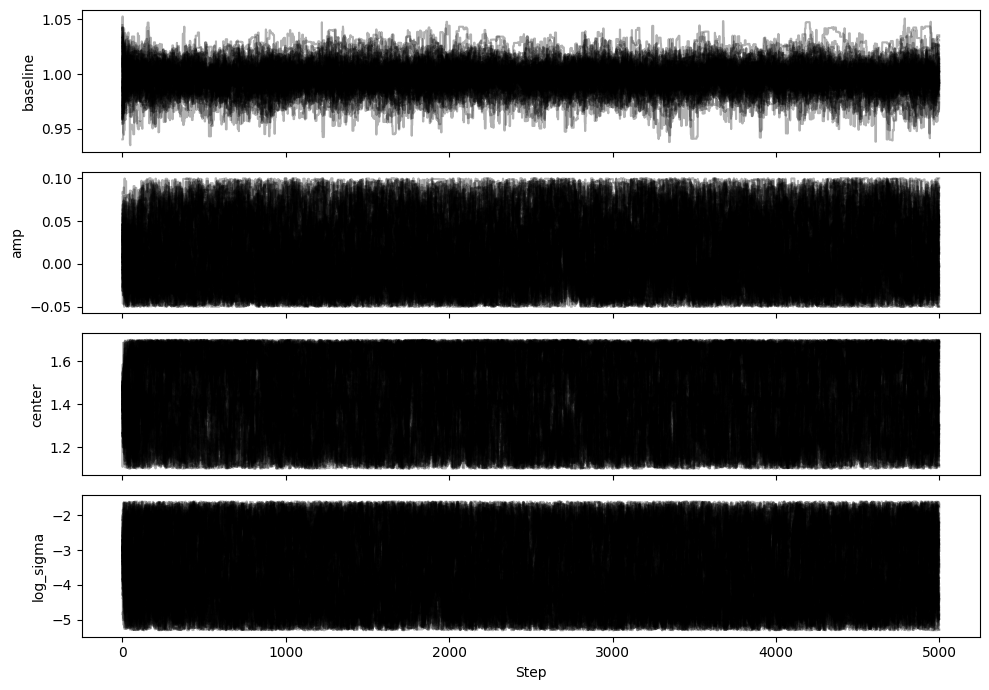

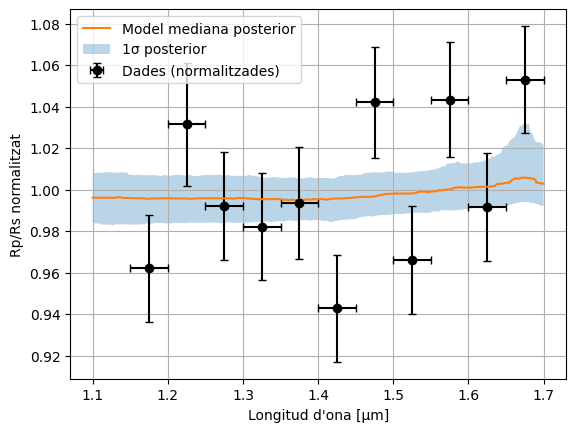


Prob. posterior P(amp > 0) = 0.630
Amp (mediana) = 0.020615  +0.046073/-0.050393


In [ ]:
# Google Colab-ready: MCMC amb emcee per detectar un pic H2O simple
# Llencem tot en una sola cel·la o en diverses segons prefereixis.

# 0) Instal·la dependències (només en Colab si cal)
!pip install --quiet emcee corner

# 1) Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import emcee
import corner
import time

# 2) Dades (les mateixes que vas donar)
data = np.array([
    [1.175, 0.05, 0.0077973252, 0.0002082651],
    [1.225, 0.05, 0.0083601016, 0.0002400672],
    [1.275, 0.05, 0.0080395881, 0.0002102117],
    [1.325, 0.05, 0.0079605045, 0.0002097295],
    [1.375, 0.05, 0.0080515811, 0.0002183603],
    [1.425, 0.05, 0.0076416553, 0.0002097285],
    [1.475, 0.05, 0.0084450288, 0.0002175522],
    [1.525, 0.05, 0.0078302323, 0.0002093257],
    [1.575, 0.05, 0.0084564130, 0.0002252069],
    [1.625, 0.05, 0.0080377671, 0.0002119293],
    [1.675, 0.05, 0.0085347202, 0.0002093527]
])
wavelength = data[:,0]
delta_w = data[:,1]
Rp_Rs_sq = data[:,2]
err = data[:,3]

# Normalitzem com abans (fa que priors siguin intel·ligibles)
Rp_Rs_sq_mean = np.mean(Rp_Rs_sq)
y = Rp_Rs_sq / Rp_Rs_sq_mean
yerr = err / Rp_Rs_sq_mean

# 3) Model: baseline + amp * Gaussian(center, sigma)
def model(w, baseline, amp, center, sigma):
    return baseline + amp * np.exp(-0.5*((w - center)/sigma)**2)

# 4) Inicialitzem amb un fit de Mínims Quadrats per tenir bons punts d'inici
p0 = [1.0, 0.02, 1.4, 0.05]  # baseline, amp, center, sigma
popt, pcov = curve_fit(model, wavelength, y, sigma=yerr, absolute_sigma=True, p0=p0)
print("Ajust inicial (least-sq):")
print(" baseline, amp, center, sigma = ", np.round(popt, 6))
print("Errors aprox (sqrt diag cov):", np.round(np.sqrt(np.diag(pcov)),6))

# 5) Definim priors i versemblança per emcee
# Paràmetres: theta = [baseline, amp, center, log_sigma]
# Treballarem amb log_sigma per garantir positivitata
def log_prior(theta):
    baseline, amp, center, log_sigma = theta
    sigma = np.exp(log_sigma)
    # Priors informatius però amplis:
    # baseline entre 0.9 i 1.1
    if not (0.9 < baseline < 1.1):
        return -np.inf
    # amp entre -0.05 i 0.1 (permès absorcio o emision lleu)
    if not (-0.05 < amp < 0.1):
        return -np.inf
    # center entre 1.1 i 1.7 (rang WFC3)
    if not (1.1 < center < 1.7):
        return -np.inf
    # sigma entre 0.005 i 0.2 microns (log prior implicit)
    if not (0.005 < sigma < 0.2):
        return -np.inf
    # Priors uniformes simples => retorn 0
    return 0.0

def log_likelihood(theta, x, y, yerr):
    baseline, amp, center, log_sigma = theta
    sigma = np.exp(log_sigma)
    model_y = model(x, baseline, amp, center, sigma)
    # Gaussiana simple
    inv_sigma2 = 1.0/(yerr**2)
    return -0.5 * np.sum((y - model_y)**2 * inv_sigma2 + np.log(2*np.pi*(yerr**2)))

def log_posterior(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

# 6) Configuració de l'MCMC
ndim = 4
nwalkers = 80  # molts walkers per a bona cobertura
# Inicia els walkers en petits passos al voltant del least-sq
initial = np.array([popt[0], popt[1], popt[2], np.log(abs(popt[3]))])
pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)
# Assegura que pos respecten priors; si algun està fora, re-ini.
for i in range(nwalkers):
    # si fora de prior, reiniciem amb random dins dels límits
    if not np.isfinite(log_prior(pos[i])):
        pos[i,0] = np.random.uniform(0.95, 1.05)       # baseline
        pos[i,1] = np.random.uniform(-0.01, 0.05)     # amp
        pos[i,2] = np.random.uniform(1.3, 1.5)        # center
        pos[i,3] = np.log(np.random.uniform(0.02, 0.08))  # sigma

# 7) Llançament d'emcee
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(wavelength, y, yerr))

nsteps = 5000  # total passi; pots reduir si vols provar ràpid
print("Running MCMC... (pot trigar uns minuts segons nsteps)")
start_time = time.time()
sampler.run_mcmc(pos, nsteps, progress=True)
end_time = time.time()
print(f"MCMC finalitzat en {end_time - start_time:.1f} s")

# 8) Convergència i descart (burn-in)
# Eliminem burn-in i aplanem
burnin = int(nsteps*0.3)  # descartar 30%
thin = 10                 # thinning per reduir autocorrelació
samples = sampler.get_chain(discard=burnin, thin=thin, flat=True)
print("Samples shape (flat):", samples.shape)

# 9) Resums estadístics
import numpy as np
labels = ["baseline", "amp", "center", "log_sigma"]
medians = np.median(samples, axis=0)
lower = np.percentile(samples, 16, axis=0)
upper = np.percentile(samples, 84, axis=0)
print("\nResum posterior (mediana + 1σ interval):")
for i, lab in enumerate(labels):
    if lab == "log_sigma":
        val = medians[i]
        val_sigma = np.exp(val)
        low = np.exp(lower[i])
        high = np.exp(upper[i])
        print(f" {lab:>8} = {val:.4f}  => sigma = {val_sigma:.4f} (+{high-val_sigma:.4f}/-{val_sigma-low:.4f})")
    else:
        print(f" {lab:>8} = {medians[i]:.6f}  (+{upper[i]-medians[i]:.6f}/-{medians[i]-lower[i]:.6f})")

# 10) Corner plot
figure = corner.corner(samples, labels=labels, truths=[None, None, None, None],
                       show_titles=True, title_fmt=".4f", title_kwargs={"fontsize":12})
plt.show()

# 11) Traçes dels walkers (opcional)
chain = sampler.get_chain()
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
param_names = labels
for i in range(ndim):
    ax = axes[i]
    ax.plot(chain[:, :, i], 'k', alpha=0.3)
    ax.set_ylabel(param_names[i])
axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()

# 12) Dibuixar el millor model amb banda d'incertesa
# Rescatem percentils per construir banda creïble
Nplot = 200
inds = np.random.randint(len(samples), size=Nplot)
w_plot = np.linspace(1.1, 1.7, 500)
models_ens = np.zeros((Nplot, len(w_plot)))
for k, idx in enumerate(inds):
    b, a, c, logs = samples[idx]
    s = np.exp(logs)
    models_ens[k,:] = model(w_plot, b, a, c, s)

# BANDA: 16-84 percentils
low_envelope = np.percentile(models_ens, 16, axis=0)
high_envelope = np.percentile(models_ens, 84, axis=0)
median_model = np.percentile(models_ens, 50, axis=0)

plt.errorbar(wavelength, y, yerr=yerr, xerr=delta_w/2, fmt='ko', capsize=3, label='Dades (normalitzades)')
plt.plot(w_plot, median_model, color='C1', label='Model mediana posterior')
plt.fill_between(w_plot, low_envelope, high_envelope, alpha=0.3, label='1σ posterior')
plt.xlabel("Longitud d'ona [μm]")
plt.ylabel("Rp/Rs normalitzat")
plt.legend()
plt.grid(True)
plt.show()

# 13) Importància estadística del paràmetre amp
amp_samples = samples[:,1]
# Probabilitat que amp > 0
p_amp_pos = np.mean(amp_samples > 0)
print(f"\nProb. posterior P(amp > 0) = {p_amp_pos:.3f}")
# valor mediana i interval
amp_median = np.median(amp_samples)
amp_16, amp_84 = np.percentile(amp_samples, [16,84])
print(f"Amp (mediana) = {amp_median:.6f}  +{amp_84-amp_median:.6f}/-{amp_median-amp_16:.6f}")